In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("ford.csv")

In [3]:
df.head(5)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [4]:
df.shape

(17966, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [6]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [7]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

<Axes: xlabel='price', ylabel='Count'>

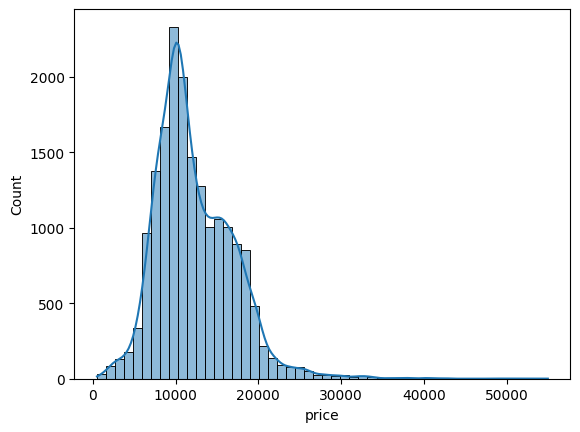

In [9]:
sns.histplot(df['price'],bins=50,kde=True)

<Axes: >

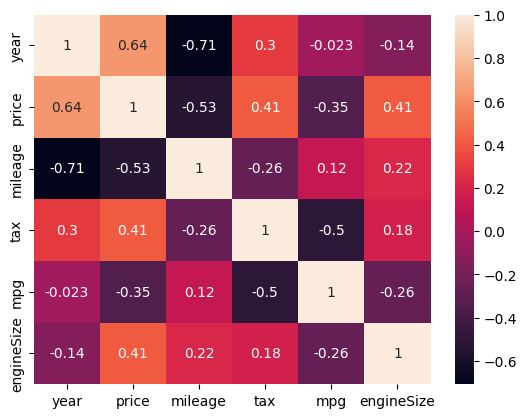

In [11]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='year', ylabel='price'>

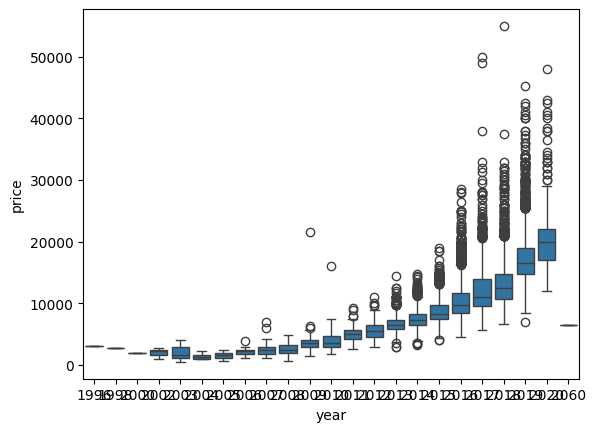

In [14]:
sns.boxplot(data=df, x='year',y='price')


<Axes: xlabel='mileage', ylabel='price'>

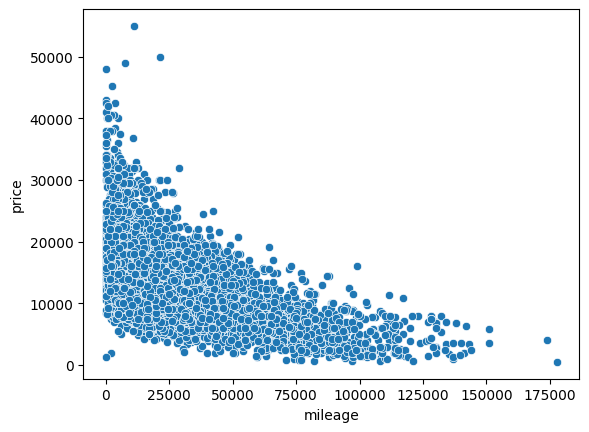

In [15]:
sns.scatterplot(data=df,x='mileage',y='price')

<Axes: xlabel='engineSize', ylabel='price'>

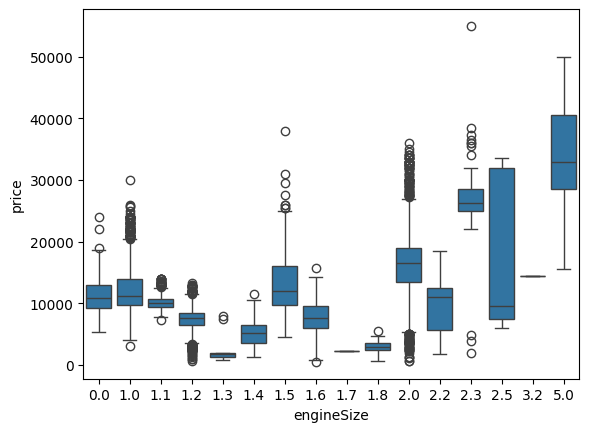

In [16]:
sns.boxplot(data=df,x='engineSize',y='price')

<Axes: xlabel='transmission', ylabel='price'>

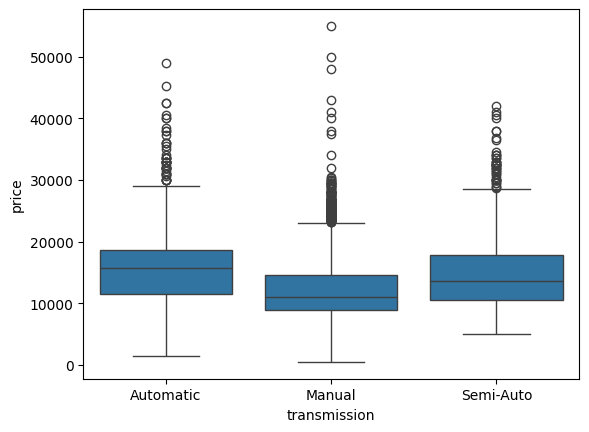

In [17]:
sns.boxplot(data=df, x='transmission',y='price')

<Axes: xlabel='fuelType', ylabel='price'>

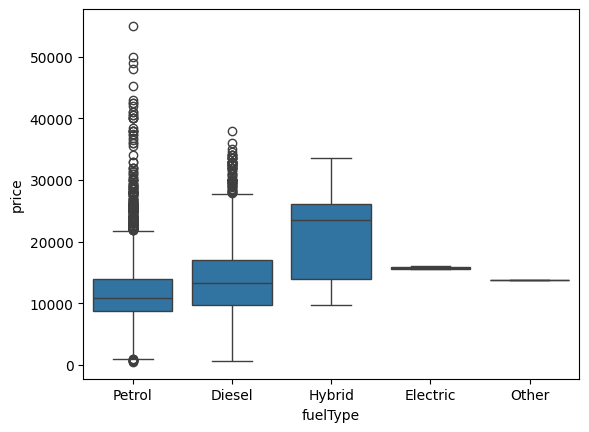

In [18]:
sns.boxplot(data=df,x='fuelType',y='price')

<Axes: xlabel='model', ylabel='price'>

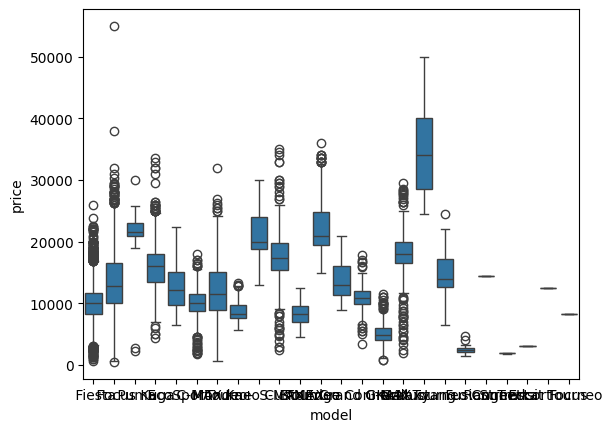

In [19]:
sns.boxplot(data=df,x='model',y='price')

In [20]:
X=df.drop(columns=['price'],axis=1)
y=df['price']

In [21]:
X_one_encode=pd.get_dummies(X,columns=["model","transmission","fuelType"],drop_first=True)

In [22]:
X_one_encode=X_one_encode.astype(int)

In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
scaler=StandardScaler()

In [25]:
numerical_cols=["year","mileage","tax","mpg","engineSize"]
X_one_encode[numerical_cols]=scaler.fit_transform(X_one_encode[numerical_cols])

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [28]:
X_train,X_test,y_train,y_test=train_test_split(X_one_encode,y,test_size=0.20,random_state=42)

In [29]:
model=LinearRegression()

In [30]:
model.fit(X_train,y_train)

LinearRegression()

In [31]:
y_pred=model.predict(X_test)

In [33]:
r2_score=r2_score(y_test,y_pred)

In [35]:
r2_score

0.8464177711972801